In [1]:
from astroquery.gaia import Gaia
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle
import astropy.units as u
import os


class GaiaLightCurveAnalyzer:
    
    def __init__(self, data_release="Gaia DR3"):
        self.data_release = data_release
        self.datalink_out = {}
        self.df = None  # store query results

    def run_query(self, query, cache_file="results.csv", overwrite_cache=False):
        """Run a Gaia query and save/load from cache."""
        if os.path.exists(cache_file) and not overwrite_cache:
            print(f"Loading cached results from {cache_file}")
            self.df = pd.read_csv(cache_file)
        else:
            print("Querying Gaia archive (this may take a while)...")
            job = Gaia.launch_job_async(query)
            results = job.get_results().to_pandas()
            results.to_csv(cache_file, index=False)
            print(f"Results cached to {cache_file}")
            self.df = results
        return self.df

    def fetch_datalink(self, source_ids, retrieval_type="EPOCH_PHOTOMETRY",
                       data_structure="INDIVIDUAL", fmt="votable"):
        """Download and merge Gaia datalink products for source IDs."""
        datalink_all = []
        for i, sid in enumerate(source_ids, start=1):
            print(f"Downloading Chunk #{i}; N_files = {len(source_ids)}")
            datalink = Gaia.load_data(ids=[sid],
                                      data_release=self.data_release,
                                      retrieval_type=retrieval_type,
                                      format=fmt,
                                      data_structure=data_structure,
                                      dump_to_file=True)
            datalink_all.append(datalink)

        datalink_out = datalink_all[0]

        print(list(datalink_out.keys())[:])
        
        for d in datalink_all[1:]:
            datalink_out.update(d)
        self.datalink_out = datalink_out
        return self.datalink_out

    def get_light_curve(self, source_id):
        """Extract light curve for a given source_id from datalink_out."""
        for key in self.datalink_out.keys():
            if str(source_id) in key:
                votable = self.datalink_out[key][0]
                return votable.to_table().to_pandas()
        raise ValueError(f"Source ID {source_id} not found in datalink.")

    def analyze_light_curve(self, df, K_values=[5], source_id=None):
        """Run Lomb-Scargle + Fourier fitting and plot results."""

        time = np.array(df["g_transit_time"])
        mag  = np.array(df["g_transit_mag"])
        mask = np.isfinite(time) & np.isfinite(mag)
        time, mag = time[mask], mag[mask]

        # Lomb–Scargle
        min_period, max_period = 0.2*u.day, 1.0*u.day
        frequency = np.linspace((1/max_period).value, (1/min_period).value, 10000)
        ls = LombScargle(time, mag)
        power = ls.power(frequency)
        best_freq = frequency[np.argmax(power)]
        best_period = 1.0 / best_freq
        omega = 2*np.pi / best_period

        # Phase fold
        phase = (time % best_period) / best_period
        order = np.argsort(phase)
        phase_sorted, mag_sorted = phase[order], mag[order]

        # Design matrix helper
        def design_matrix(t, K, omega):
            cols = [np.ones_like(t)]
            for k in range(1, K+1):
                cols.append(np.sin(k*omega*t))
            for k in range(1, K+1):
                cols.append(np.cos(k*omega*t))
            return np.vstack(cols).T

        rms_results = {}
        for K in K_values:
            X = design_matrix(time, K, omega)
            beta, *_ = np.linalg.lstsq(X, mag, rcond=None)
            mag_model = X.dot(beta)
    
            resid = mag - mag_model
            rms = np.sqrt(np.mean(resid**2))
            rms_results[K] = rms
    
            # Model curve
            t_grid = np.linspace(time.min(), time.min()+best_period, 2000)
            phase_grid = (t_grid % best_period) / best_period
            X_grid = design_matrix(t_grid, K, omega)
            mag_grid = X_grid.dot(beta)
    
            # Plot
            plt.figure(figsize=(10,5))
            plt.scatter(phase_sorted, mag_sorted, s=20, alpha=0.6, label="Data")
            plt.plot(phase_grid, mag_grid, lw=1.5, label=f"Fourier fit (K={K})")
            plt.gca().invert_yaxis()
            plt.xlabel("Phase")
            plt.ylabel("G mag")
    
            sid_text = f" (Source ID {source_id})" if source_id else ""
            plt.title(f"Period = {best_period:.4f} d, RMS={rms:.4f}{sid_text}")
            plt.legend()
            plt.grid(alpha=0.3)
            plt.show()

        
        print("Summary RMS:", rms_results)
        return best_period, rms_results



In [2]:
analyzer = GaiaLightCurveAnalyzer()

query_part_23 = """
SELECT TOP 1000

gaia.source_id, 
gaia.ra,
gaia.dec,
gaia.parallax,
gaia.parallax_error,
gaia.b,
gaia.ruwe,
gaia.bp_rp,
gaia.phot_bp_mean_flux,
gaia.phot_bp_mean_flux_error,
gaia.phot_bp_mean_flux_over_error,
gaia.phot_rp_mean_flux,
gaia.phot_rp_mean_flux_error,
gaia.phot_rp_mean_flux_over_error,
gaia.phot_bp_rp_excess_factor,
sosrrl.pf, 
sosrrl.epoch_g,
sosrrl.int_average_g,
sosrrl.int_average_g_error

FROM gaiadr3.gaia_source AS gaia

LEFT OUTER JOIN gaiadr3.vari_rrlyrae AS sosrrl USING (source_id)

where parallax_over_error > 5

AND ABS(b) > 30

AND (1000.0/parallax) < 4000

AND sosrrl.pf IS NOT NULL

     
"""



df_part_23 = analyzer.run_query(query_part_23, cache_file="lab01_ch3_part23.csv")


Loading cached results from lab01_ch3_part23.csv


In [3]:
# Quality cuts from Lindegren et al. 2018
mask_ruwe = df_part_23["ruwe"] < 1.4

bp_rp = df_part_23["bp_rp"]
excess = df_part_23["phot_bp_rp_excess_factor"]

lower_bound = 1.0 + 0.015 * (bp_rp**2)
upper_bound = 1.3 + 0.06 * (bp_rp**2)
mask_excess = (excess > lower_bound) & (excess < upper_bound)


mask_good = mask_ruwe & mask_excess

df_clean = df_part_23[mask_good]

print(f"Original sample: {len(df_part_23)} stars")
print(f"After quality cuts: {len(df_clean)} stars")

Original sample: 674 stars
After quality cuts: 449 stars


In [4]:
MAG_FACTOR = 1.0857  # = 2.5 / ln(10)

f_bp = df_clean["phot_bp_mean_flux"]
f_bp_err = df_clean["phot_bp_mean_flux_error"]
f_rp = df_clean["phot_rp_mean_flux"]
f_rp_err = df_clean["phot_rp_mean_flux_error"]

# # Avoid division by zero
# valid = (f_bp > 0) & (f_rp > 0)

# Compute color uncertainty
sigma_color = MAG_FACTOR * np.sqrt( (f_bp_err / f_bp)**2 + (f_rp_err / f_rp)**2)

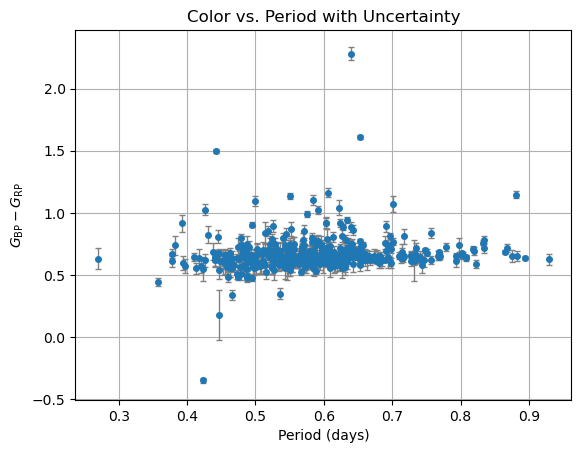

In [5]:
plt.errorbar(df_clean['pf'], df_clean["bp_rp"], yerr=sigma_color,
             fmt='o', ecolor='gray', elinewidth=1, capsize=2, markersize=4)
plt.xlabel('Period (days)')
plt.ylabel(r'$G_{\mathrm{BP}} - G_{\mathrm{RP}}$')
plt.title('Color vs. Period with Uncertainty')
plt.grid(True)
plt.show()

In [6]:

bp_rp = df_clean['bp_rp'].values
period = df_clean['pf'].values
logP = np.log10(period)

mask = np.isfinite(bp_rp) & np.isfinite(logP) & np.isfinite(sigma_color) & (sigma_color > 0)
bp_rp = bp_rp[mask]
logP = logP[mask]
sigma_color = sigma_color[mask]


In [7]:
import pymc as pm
import arviz as az


with pm.Model() as model:
    a = pm.Normal('a', mu=0.0, sigma=2.0)
    b = pm.Normal('b', mu=0.0, sigma=2.0)
    log_sigma = pm.Normal('log_sigma', mu=-2.0, sigma=2.0)
    sigma_scatter = pm.Deterministic('sigma_scatter', pm.math.exp(log_sigma))

    mu = a * logP + b
    sigma_tot = pm.math.sqrt(sigma_scatter**2 + sigma_color**2 + 1e-6)

    pm.Normal('obs', mu=mu, sigma=sigma_tot, observed=bp_rp)

    idata = pm.sample(2000, tune=2000, target_accept=0.95, cores=4)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, log_sigma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 2 seconds.


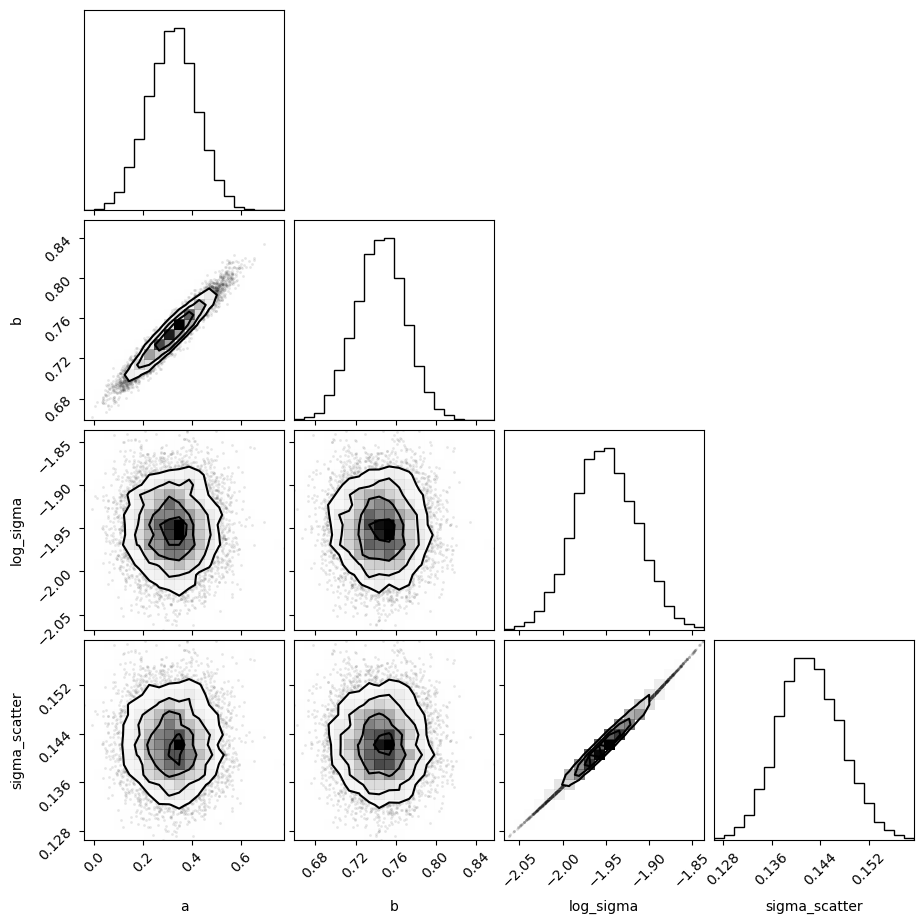

In [8]:
import corner

_ = corner.corner(idata)

In [9]:
# Extract posterior samples
a_samples = idata.posterior['a'].values.flatten()
b_samples = idata.posterior['b'].values.flatten()
# Make a smooth grid in logP
logP_grid = np.linspace(logP.min(), logP.max(), 200)
P_grid = logP_grid

Slope (a): 0.3195 (68% CI: 0.2196, 0.4179)
Intercept (b): 0.7451 (68% CI: 0.7216, 0.7705)


/var/folders/wk/x7r25gnx1nd_fmk13dz2gn440000gn/T/ipykernel_2005/3361470397.py:15: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  mu_hpd = az.hdi(mu_pred, hdi_prob=0.68)


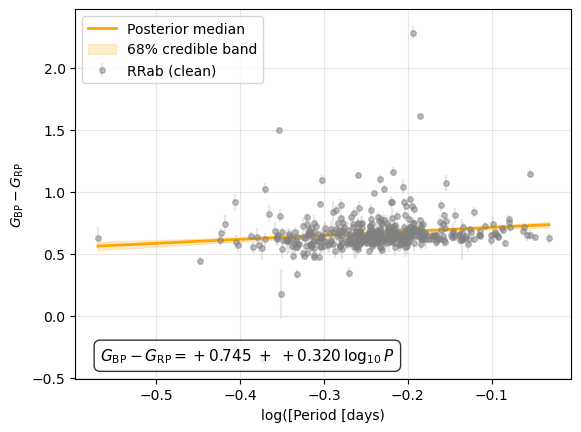

In [10]:

import numpy as np
import matplotlib.pyplot as plt
import arviz as az
import matplotlib.ticker as ticker

# Compute posterior summaries
a_mean = a_samples.mean()
b_mean = b_samples.mean()
a_hdi = az.hdi(a_samples, hdi_prob=0.68)
b_hdi = az.hdi(b_samples, hdi_prob=0.68)

mu_pred = np.outer(a_samples, logP_grid) + b_samples[:, None]
# Compute mean and 1 credible intervals
mu_mean = mu_pred.mean(axis=0)
mu_hpd = az.hdi(mu_pred, hdi_prob=0.68)

logP_grid = np.linspace(logP.min(), logP.max(), 200)
P_grid = logP_grid

print(f"Slope (a): {a_mean:.4f} (68% CI: {a_hdi[0]:.4f}, {a_hdi[1]:.4f})")
print(f"Intercept (b): {b_mean:.4f} (68% CI: {b_hdi[0]:.4f}, {b_hdi[1]:.4f})")


# Plot observed data
plt.errorbar(logP, bp_rp, yerr=sigma_color, fmt='o', ms=4, color='gray', alpha=0.5,
             ecolor='lightgray', label='RRab (clean)')

# Posterior mean and 68% credible band
plt.plot(P_grid, mu_mean, color='orange', lw=2, label='Posterior median')
plt.fill_between(P_grid, mu_hpd[:, 0], mu_hpd[:, 1], color='orange', alpha=0.2, label='68% credible band')

# Add regression equation
eq_text = fr'$G_{{\rm BP}} - G_{{\rm RP}} = {b_mean:+.3f} \;+\; {a_mean:+.3f}\,\log_{{10}}P$'
plt.text(
    0.05, 0.05,
    eq_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=0.4')
)

plt.xlabel('log([Period [days)')
plt.ylabel(r'$G_{\mathrm{BP}} - G_{\mathrm{RP}}$')
# plt.title('RRab: Period–color relation (Gaia bands)')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("Period–color relation (Gaia bands).jpeg")
plt.show()


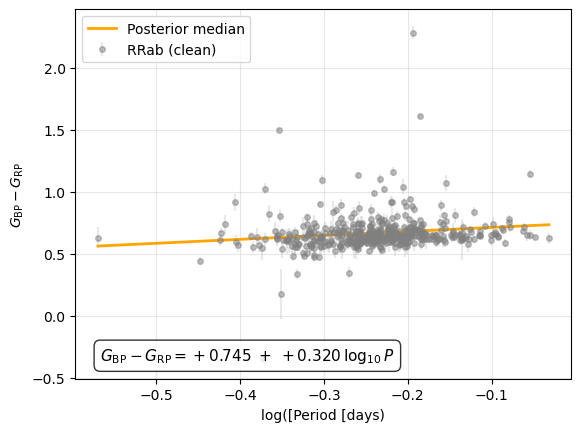

In [12]:
# Plot observed data
plt.errorbar(logP, bp_rp, yerr=sigma_color, fmt='o', ms=4, color='gray', alpha=0.5,
             ecolor='lightgray', label='RRab (clean)')

# Posterior mean and 68% credible band
plt.plot(P_grid, mu_mean, color='orange', lw=2, label='Posterior median')
# plt.fill_between(P_grid, mu_hpd[:, 0], mu_hpd[:, 1], color='orange', alpha=0.2, label='68% credible band')

# Add regression equation
eq_text = fr'$G_{{\rm BP}} - G_{{\rm RP}} = {b_mean:+.3f} \;+\; {a_mean:+.3f}\,\log_{{10}}P$'
plt.text(
    0.05, 0.05,
    eq_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=0.4')
)

plt.xlabel('log([Period [days)')
plt.ylabel(r'$G_{\mathrm{BP}} - G_{\mathrm{RP}}$')
# plt.title('RRab: Period–color relation (Gaia bands)')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("Period–color realtion.jpeg")
plt.show()

In [11]:
analyzer = GaiaLightCurveAnalyzer()

# First query: RRc
query_24 = """
SELECT 
gaia.source_id, 
gaia.parallax,
gaia.ra,
gaia.dec,
gaia.b,
gaia.ruwe,
gaia.bp_rp,
gaia.phot_bp_mean_flux,
gaia.phot_bp_mean_flux_error,
gaia.phot_bp_mean_flux_over_error,
gaia.phot_rp_mean_flux,
gaia.phot_rp_mean_flux_error,
gaia.phot_rp_mean_flux_over_error,
gaia.phot_bp_rp_excess_factor,
sosrrl.pf, 
sosrrl.g_absorption,
sosrrl.epoch_g,
sosrrl.int_average_g,
sosrrl.int_average_g_error

FROM gaiadr3.gaia_source AS gaia

LEFT OUTER JOIN gaiadr3.vari_rrlyrae AS sosrrl USING (source_id)

WHERE sosrrl.pf IS NOT NULL

AND sosrrl.g_absorption IS NOT NULL

"""

df_24 = analyzer.run_query(query_24, cache_file="lab01_part_24.csv")


Loading cached results from lab01_part_24.csv


In [12]:
MAG_FACTOR = 1.0857  # = 2.5 / ln(10)

f_bp_24 = df_24["phot_bp_mean_flux"]
f_bp_err_24 = df_24["phot_bp_mean_flux_error"]
f_rp_24 = df_24["phot_rp_mean_flux"]
f_rp_err_24 = df_24["phot_rp_mean_flux_error"]

# # Avoid division by zero
# valid = (f_bp > 0) & (f_rp > 0)

# Compute color uncertainty
sigma_color_24 = MAG_FACTOR * np.sqrt( (f_bp_err_24 / f_bp_24)**2 + (f_rp_err_24 / f_rp_24)**2)

In [13]:
bp_rp_24 = df_24['bp_rp'].values
period_24 = df_24['pf'].values
logP_24 = np.log10(period_24)

# mask_24 = np.isfinite(bp_rp_24) & np.isfinite(logP_24) & np.isfinite(sigma_color_24) & (sigma_color_24 > 0)
# bp_rp_24 = bp_rp_24[mask_24]
# logP_24 = logP_24[mask_24]
# sigma_color_24 = sigma_color_24[mask_24]


In [14]:
import pymc as pm
import arviz as az


with pm.Model() as model:
    a = pm.Normal('a', mu=0.0, sigma=2.0)
    b = pm.Normal('b', mu=0.0, sigma=2.0)
    log_sigma = pm.Normal('log_sigma', mu=-2.0, sigma=2.0)
    sigma_scatter = pm.Deterministic('sigma_scatter', pm.math.exp(log_sigma))

    mu = a * logP_24 + b
    sigma_tot = pm.math.sqrt(sigma_scatter**2 + sigma_color_24**2 + 1e-6)

    pm.Normal('obs', mu=mu, sigma=sigma_tot, observed=bp_rp_24)

    idata2 = pm.sample(2000, tune=2000, target_accept=0.95, cores=4)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, log_sigma]


Output()

ValueError: Not enough samples to build a trace.

In [ ]:
logP_24 = np.log10(df_24['pf'].values)
obs_color_24 = (df_24['bp_rp']).values

RG = 2.0
a_samps = idata2.posterior['a'].values.reshape(-1)
b_samps = idata2.posterior['b'].values.reshape(-1)

intrinsic_pred = a_samps[:, None] * logP_24[None, :] + b_samps[:, None]
E_samples = obs_color_24[None, :] - intrinsic_pred
AG_samples = RG * E_samples

print(AG_samples.shape)  # (n_draws, 170107)

In [ ]:
# Compute posterior mean AG for each star
AG_mean = AG_samples.mean(axis=0)
E_mean = E_samples.mean(axis=0)
# Add to the dataframe
df_24['A_G_calc'] = AG_mean
df_24['A_G_catalog'] = df_24['g_absorption']

# Plot comparison
plt.figure(figsize=(7,6))
plt.scatter(E_mean,df_24['A_G_catalog'], alpha=0.4,label = 'Observed')
plt.scatter(E_mean,df_24['A_G_calc'], alpha=0.4,label = 'Calculated')
# plt.plot([0, 5], [0, 5], 'r--', label='1:1 line')
plt.xlabel('Catalog A_G (g_absorption)')
plt.ylabel('Calculated A_G')
plt.title('Comparison of Calculated vs Catalog A_G')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
# Plot comparison
plt.figure(figsize=(7,6))
plt.scatter(E_mean,df_24['A_G_catalog'], alpha=0.4,s=0.6,label = 'Observed')
plt.plot(E_mean,df_24['A_G_calc'], alpha=0.4,c='black',label = 'Calculated')
# plt.plot([0, 5], [0, 5], 'r--', label='1:1 line')
plt.xlabel(r'$E(G_{\mathrm{BP}} - G_{\mathrm{RP}}$)_sampled')
plt.ylabel('A_G')
plt.title('Comparison of Calculated vs Catalog A_G')
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0,6)
plt.show()
print(AG_mean)

In [ ]:
from scipy.stats import pearsonr
r, _ = pearsonr(df_24['g_absorption'], df_24['A_G_calc'])
print(f"Pearson correlation r = {r:.3f}")


In [ ]:
# Compute residuals
df_24['A_G_residual'] = df_24['A_G_calc'] - df_24['g_absorption']

plt.figure(figsize=(8,5))
plt.scatter(df_24['b'], df_24['A_G_residual'], 
            alpha=0.4, s=8, color='C0')
plt.axhline(0, color='r', linestyle='--', label='No offset')
plt.xlabel('Galactic Latitude b [deg]')
plt.ylabel(r'$\Delta A_G = A_G^{calc} - A_G^{catalog}$')
plt.title('Residuals of Calculated vs. Catalog A_G vs Galactic Latitude')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
E_mean = E_samples.mean(axis=0)

# Convert to radians for Aitoff projection
lon = np.radians(df_24['ra'].values)
lat = np.radians(df_24['b'].values)

# Wrap longitudes to [-π, π]
lon = np.remainder(lon + np.pi, 2*np.pi) - np.pi

# Plot
plt.figure(figsize=(10,6))
plt.subplot(111, projection="aitoff")
sc = plt.scatter(lon, lat, c=E_mean, cmap='viridis', s=8, alpha=0.7)
plt.colorbar(sc, label=r'$E(G_{BP}-G_{RP})$')
plt.title('Color Excess Map in Galactic Coordinates (Aitoff Projection)')
plt.grid(True)
plt.show()

In [ ]:
mask_ruwe = df_24["ruwe"] < 1.4

bp_rp = df_24["bp_rp"]
excess = df_24["phot_bp_rp_excess_factor"]

lower_bound = 1.0 + 0.015 * (bp_rp**2)
upper_bound = 1.3 + 0.06 * (bp_rp**2)
mask_excess = (excess > lower_bound) & (excess < upper_bound)

snr_bp = df_24["phot_bp_mean_flux_over_error"] > 20
snr_rp = df_24["phot_rp_mean_flux_over_error"] > 20

mask_good = mask_ruwe & mask_excess & snr_bp & snr_rp
df_24_clean = df_24[mask_good]


In [ ]:
# Apply cuts to df_24
mask_ruwe = df_24["ruwe"] < 1.4
bp_rp = df_24["bp_rp"]
excess = df_24["phot_bp_rp_excess_factor"]
lower_bound = 1.0 + 0.015 * (bp_rp**2)
upper_bound = 1.3 + 0.06 * (bp_rp**2)
mask_excess = (excess > lower_bound) & (excess < upper_bound)
snr_bp = df_24["phot_bp_mean_flux_over_error"] > 20
snr_rp = df_24["phot_rp_mean_flux_over_error"] > 20

mask_good = mask_ruwe & mask_excess & snr_bp & snr_rp
df_24_clean = df_24[mask_good]

# Now recompute E_mean only for the cleaned sample
E_mean_clean = E_samples.mean(axis=0)[mask_good]




In [ ]:
# Convert coords using RA/Dec from the same cleaned sample
from astropy.coordinates import SkyCoord
import astropy.units as u

coords = SkyCoord(ra=df_24_clean['ra'].values*u.deg,
                  dec=df_24_clean['dec'].values*u.deg,
                  frame='icrs')
l = coords.galactic.l.wrap_at(180*u.deg).radian
b = coords.galactic.b.radian

# Plot the clean Aitoff map
plt.figure(figsize=(10,6))
plt.subplot(111, projection="aitoff")
sc = sc = plt.scatter(l, b, c=E_mean_clean, cmap='plasma', s=0.5, alpha=0.7, edgecolors='none')
plt.colorbar(sc, label=r'$E(G_{\mathrm{BP}} - G_{\mathrm{RP}})$')
# plt.title('Color Excess Map in Galactic Coordinates (Cleaned Sample)', pad=25)
plt.grid(True)
plt.savefig('own dust map.jpeg')
plt.show()


In [ ]:
print(len(l))

In [ ]:
from dustmaps.sfd import SFDQuery
from dustmaps import sfd

# Only run once to download the SFD map (~35 MB)
sfd.fetch()

# Now initialize the query object
sfd_query = SFDQuery()

# Sample SFD at your RR Lyrae positions
ebv_sfd = sfd_query(coords)



In [ ]:
plt.figure(figsize=(10, 7))
plt.subplot(111, projection="aitoff")
sc = plt.scatter(l, b, c=ebv_sfd, cmap='plasma', s=0.5, alpha=0.7, edgecolors='none')
plt.colorbar(sc, label=r'$E(B - V)$ (SFD)')
# plt.title('SFD Reddening Map at RR Lyrae Positions', pad=20)
plt.grid(True)
plt.savefig('sfd map.jpeg')
plt.show()


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(ebv_sfd, E_mean_clean, s=1, alpha=0.3)
plt.xlabel(r'$E(B - V)$ (SFD)')
plt.ylabel(r'$E(G_{\mathrm{BP}} - G_{\mathrm{RP}})$ (RR Lyrae)')
plt.title('Comparison of SFD and RR Lyrae Reddening')
plt.grid(True)
plt.show()


In [ ]:
print(len(ebv_sfd))